In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36779,Workers: 16
Dashboard: http://127.0.0.1:8787/status,Total threads: 128
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:42309,Total threads: 8
Dashboard: http://127.0.0.1:35669/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:43247,


### Load MITgcm Output from Assimilations (with and without velocity)

In [2]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/TPOSE_TAO/'

In [3]:
data_dir = '/data/shared_data/Interp_Profiles/regional/TP/TAO/'

## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

### Load TAO CTD data

In [4]:
data_dir = '/data/shared_data/Interp_Profiles/regional/TP/TAO/'

ds2012 = xr.open_dataset(data_dir + 'TAO_WO_2012_CTD_daily.nc')
ds2013 = xr.open_dataset(data_dir + 'TAO_WO_2013_CTD_daily.nc')

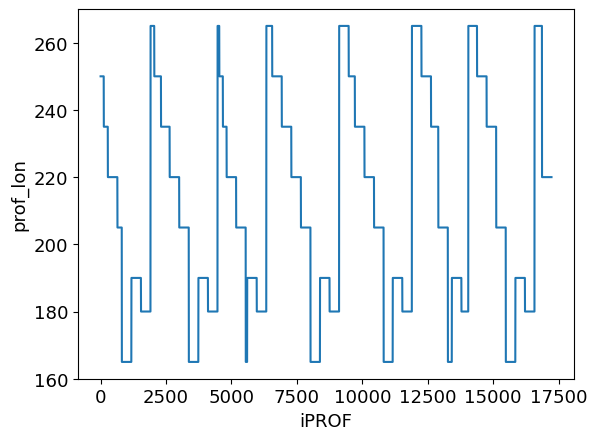

In [5]:
ds2012.prof_lon.plot()

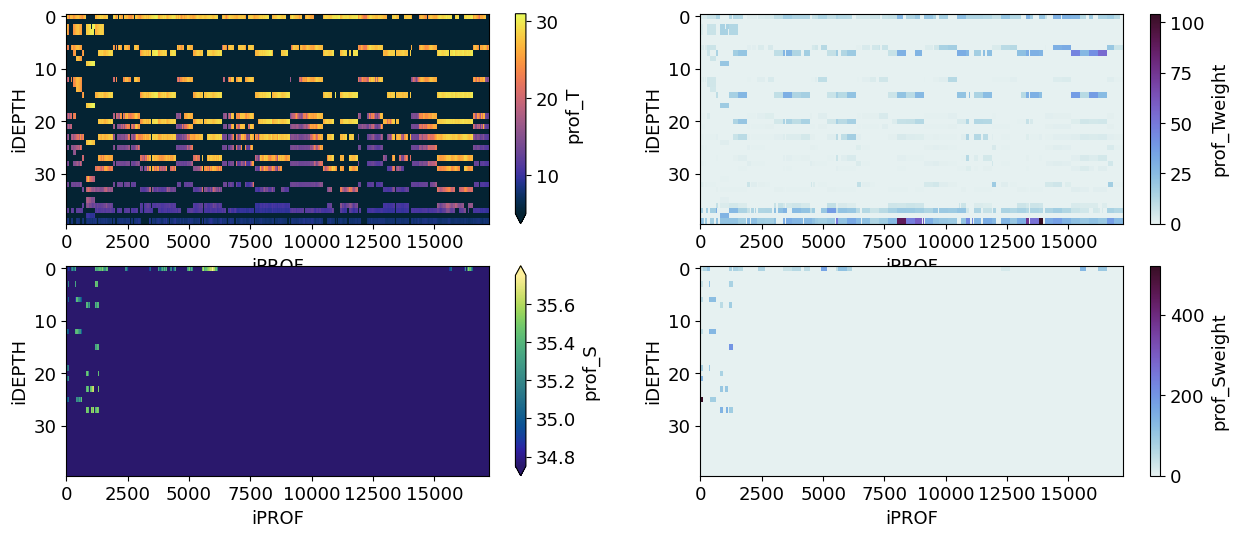

In [6]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2,ncols=2)
ds2012.prof_T.plot(x='iPROF',ax=ax[0,0],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,0].invert_yaxis()
ds2012.prof_Tweight.plot(x='iPROF',ax=ax[0,1],cmap=cmo.dense)
ax[0,1].invert_yaxis()
ds2012.prof_S.plot(x='iPROF',ax=ax[1,0],vmin=34.75,vmax=35.75,cmap=cmo.haline)
ax[1,0].invert_yaxis()
ds2012.prof_Sweight.plot(x='iPROF',ax=ax[1,1],cmap=cmo.dense)
ax[1,1].invert_yaxis()

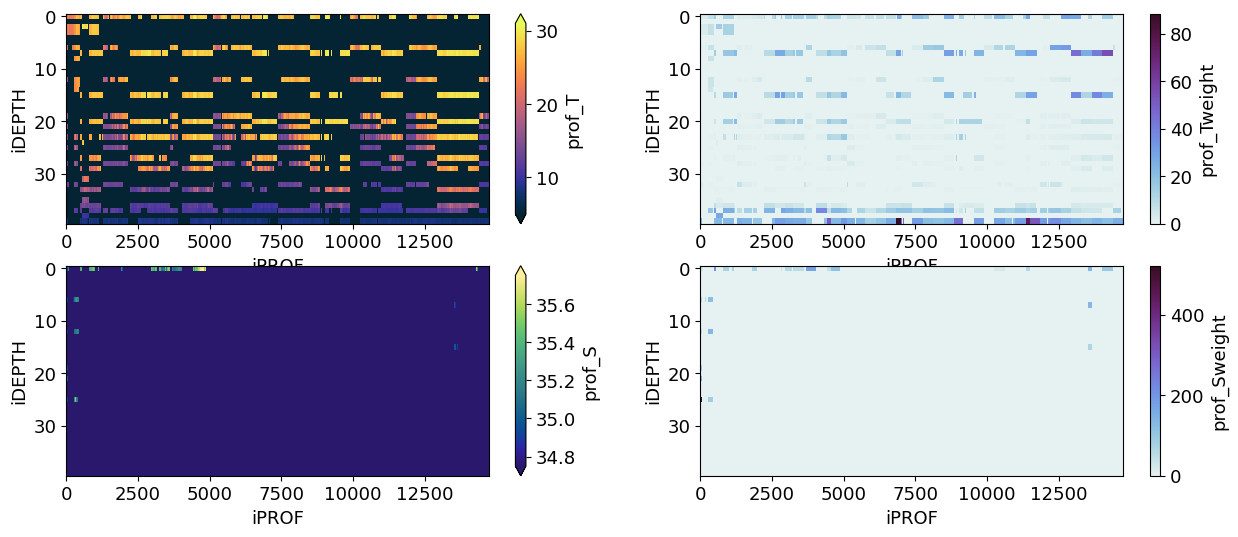

In [7]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2,ncols=2)
ds2013.prof_T.plot(x='iPROF',ax=ax[0,0],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,0].invert_yaxis()
ds2013.prof_Tweight.plot(x='iPROF',ax=ax[0,1],cmap=cmo.dense)
ax[0,1].invert_yaxis()
ds2013.prof_S.plot(x='iPROF',ax=ax[1,0],vmin=34.75,vmax=35.75,cmap=cmo.haline)
ax[1,0].invert_yaxis()
ds2013.prof_Sweight.plot(x='iPROF',ax=ax[1,1],cmap=cmo.dense)
ax[1,1].invert_yaxis()

In [8]:
data_dir = '/data/SO6/TPOSE/constraints/profiles/'

In [9]:
dsMRB = xr.open_dataset(data_dir + 'NODC_TP_2012_MRB_w.nc')
ds2013 = xr.open_dataset(data_dir + 'NODC_TP_2013_MRB_w.nc')

# dsMRB = xr.concat([ds2012, ds2013],dim='iPROF')

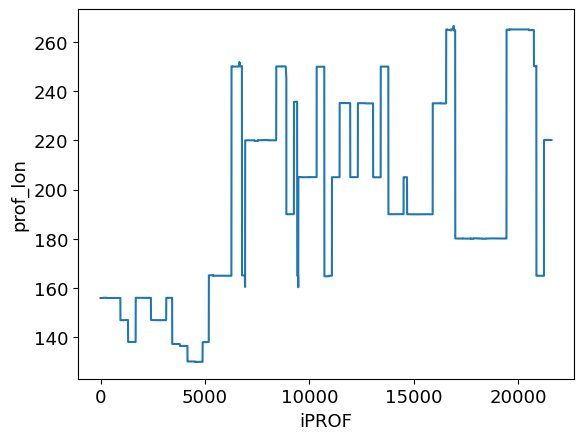

In [11]:
dsMRB.prof_lon.plot()

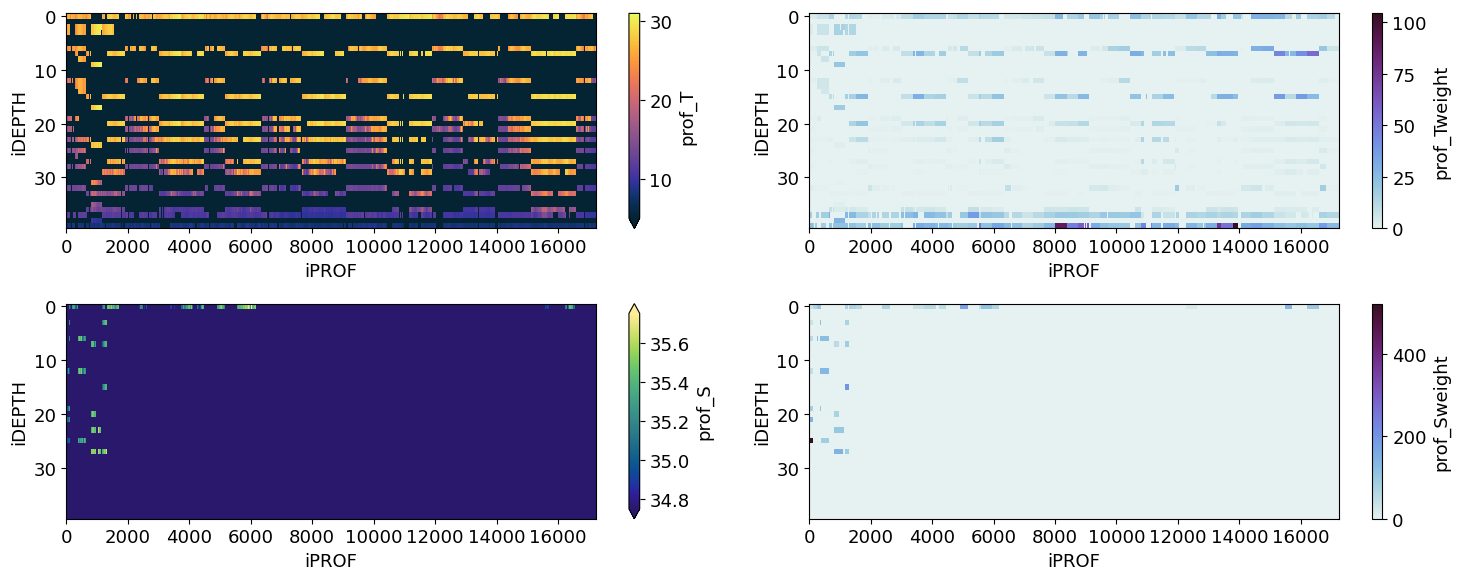

In [12]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2,ncols=2)
ds2012.prof_T.plot(x='iPROF',ax=ax[0,0],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,0].invert_yaxis()
ds2012.prof_Tweight.plot(x='iPROF',ax=ax[0,1],cmap=cmo.dense)
ax[0,1].invert_yaxis()
ds2012.prof_S.plot(x='iPROF',ax=ax[1,0],vmin=34.75,vmax=35.75,cmap=cmo.haline)
ax[1,0].invert_yaxis()
ds2012.prof_Sweight.plot(x='iPROF',ax=ax[1,1],cmap=cmo.dense)
ax[1,1].invert_yaxis()
plt.tight_layout()

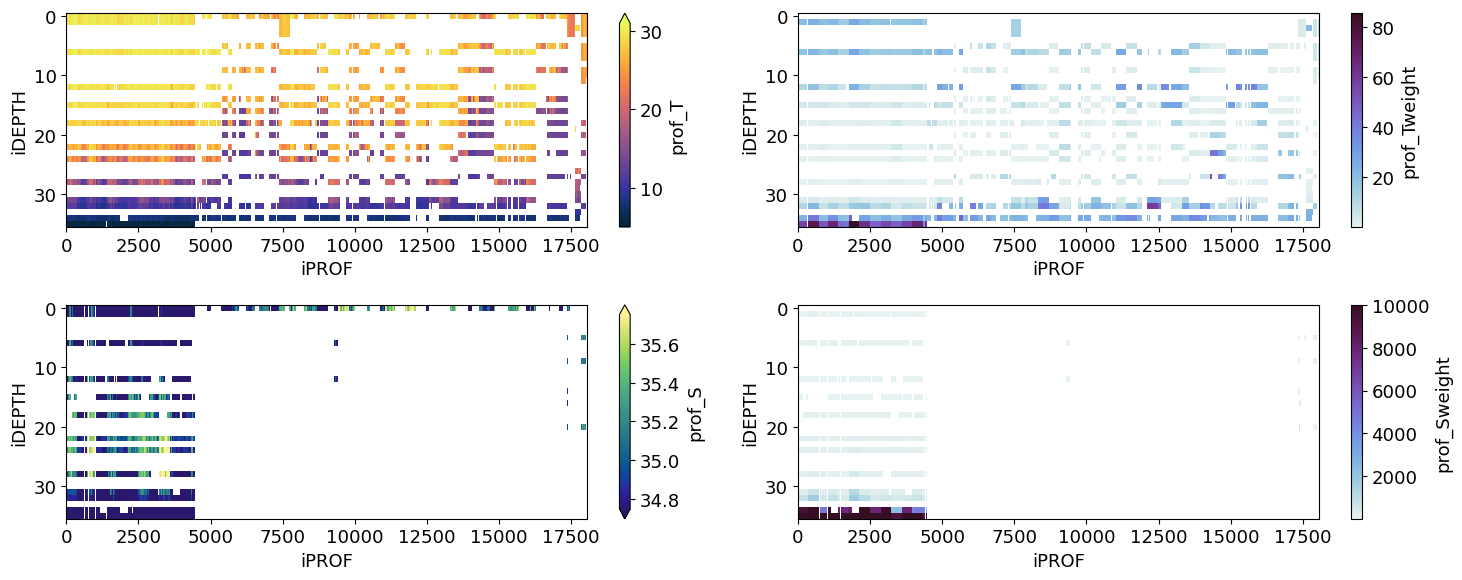

In [13]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2,ncols=2)
ds2013.prof_T.plot(x='iPROF',ax=ax[0,0],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,0].invert_yaxis()
ds2013.prof_Tweight.plot(x='iPROF',ax=ax[0,1],cmap=cmo.dense)
ax[0,1].invert_yaxis()
ds2013.prof_S.plot(x='iPROF',ax=ax[1,0],vmin=34.75,vmax=35.75,cmap=cmo.haline)
ax[1,0].invert_yaxis()
ds2013.prof_Sweight.plot(x='iPROF',ax=ax[1,1],cmap=cmo.dense)
ax[1,1].invert_yaxis()
plt.tight_layout()

In [16]:
import pandas as pd
dates = dsMRB['prof_YYYYMMDD'].values.astype(int)
times = dsMRB['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')
dsMRB = dsMRB.assign_coords(time=("iPROF", datetimes))

dsMRB = dsMRB.assign_coords(
    lon = ("iPROF", ((dsMRB.prof_lon / 0.25).round() * 0.25).data),
    lat = ("iPROF", ((dsMRB.prof_lat / 0.25).round() * 0.25).data)
)

# Assign as coordinate and optionally swap dimensions
dsMRB = dsMRB.assign_coords(time=('iPROF', datetimes))
dsMRB = dsMRB.assign_coords(depth=('iDEPTH', dsMRB['prof_depth'].values*-1))
# ds = ds.swap_dims({'iPROF': 'time'})

In [17]:
ts_by_lon = dsMRB.groupby("lon")
ts_by_lon.groups.keys()

dict_keys([130.0, 130.25, 136.5, 137.25, 138.0, 138.25, 147.0, 156.0, 160.25, 160.5, 161.0, 161.5, 161.75, 162.0, 162.5, 162.75, 163.0, 163.5, 163.75, 164.0, 164.25, 164.75, 165.0, 165.25, 180.0, 180.25, 190.0, 205.0, 219.75, 220.0, 220.25, 235.0, 235.25, 235.5, 235.75, 245.0, 245.25, 245.5, 245.75, 246.0, 246.25, 246.5, 246.75, 247.0, 247.25, 247.5, 247.75, 248.0, 248.25, 248.5, 248.75, 249.0, 249.25, 249.5, 249.75, 250.0, 250.25, 251.25, 251.5, 251.75, 264.5, 264.75, 265.0, 265.25, 265.5, 265.75, 266.0, 266.25, 266.5])

In [18]:
ds_140 = dsMRB.where(dsMRB.lat > -0.25, drop=True)
ds_140 = ds_140.where(ds_140.lat < 0.25, drop=True)
ds_140 = ds_140.where(ds_140.lon < 220.25, drop=True)
ds_140 = ds_140.where(ds_140.lon > 219.75, drop=True)

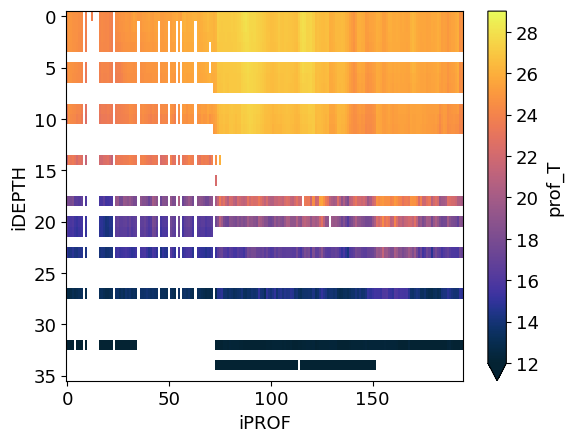

In [20]:
ds_140.prof_T.plot(x='iPROF',y='iDEPTH',yincrease=False,vmin=12,vmax=29,cmap=cmo.thermal)

In [21]:
data_dir = '/data/shared_data/Interp_Profiles/regional/TP/TAO/'

dsTAO = xr.open_dataset(data_dir + 'TAO_WO_2012_CTD_daily.nc')

# Combine date and time into a datetime array
dates = dsTAO['prof_YYYYMMDD'].values.astype(int)
times = dsTAO['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
dsTAO = dsTAO.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
dsTAO = dsTAO.assign_coords(depth=('iDEPTH', dsTAO['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
dsTAO = dsTAO.assign_coords(lat=('iPROF', dsTAO['prof_lat'].values))
dsTAO = dsTAO.assign_coords(lon=('iPROF', dsTAO['prof_lon'].values))

In [24]:
dsTAO.prof_lon

<xarray.DataArray 'prof_lon' (iPROF: 17227)> Size: 138kB
array([250., 250., 250., ..., 220., 220., 220.])
Coordinates:
    time     (iPROF) datetime64[ns] 138kB 2012-01-01 2012-01-02 ... 2012-12-31
    lat      (iPROF) float64 138kB 0.0 0.0 0.0 0.0 0.0 ... 9.0 9.0 9.0 9.0 9.0
    lon      (iPROF) float64 138kB 250.0 250.0 250.0 250.0 ... 220.0 220.0 220.0
Dimensions without coordinates: iPROF

In [25]:
dsMRB.prof_lon

<xarray.DataArray 'prof_lon' (iPROF: 21603)> Size: 173kB
array([155.95, 155.95, 155.95, ..., 220.12, 220.12, 220.12])
Coordinates:
    time     (iPROF) datetime64[ns] 173kB 2012-01-01 2012-01-02 ... 2012-12-31
    lon      (iPROF) float64 173kB 156.0 156.0 156.0 156.0 ... 220.0 220.0 220.0
    lat      (iPROF) float64 173kB -0.0 -0.0 -0.0 -0.0 -0.0 ... nan nan 0.0 0.0
Dimensions without coordinates: iPROF
Attributes:
    dimension:  (degree E)

In [30]:
# group profiles by longitude (these are all equatorial TAO moorings)
TAO_by_lon = dsTAO.groupby('lon')
# check that for a single longitude, time is monotonically increasing 
ds_TAO_140 = dsTAO.where(dsTAO.lat > -0.25, drop=True)
ds_TAO_140 = ds_TAO_140.where(ds_TAO_140.lat < 0.25, drop=True)
ds_TAO_140 = ds_TAO_140.where(ds_TAO_140.lon < 220.25, drop=True)
ds_TAO_140 = ds_TAO_140.where(ds_TAO_140.lon > 219.75, drop=True)

(-600.0, 0.0)

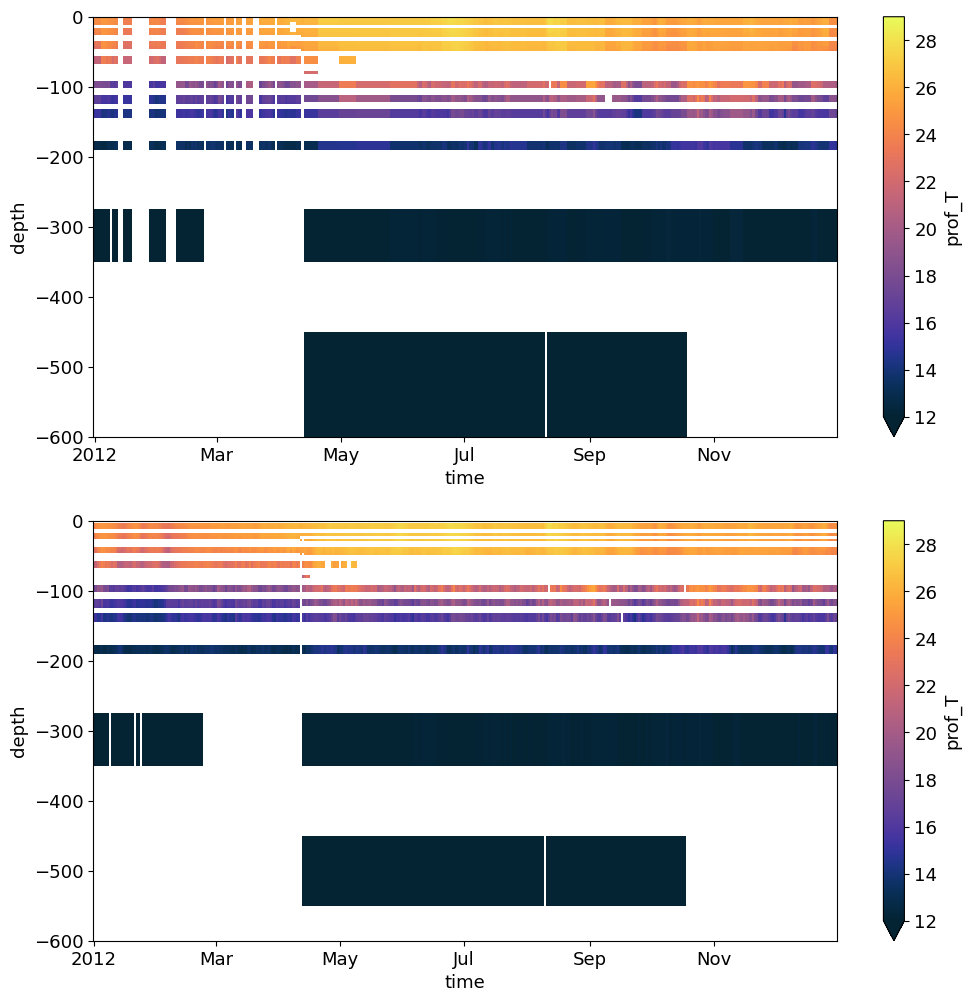

In [38]:
# replace -9999 in dsTAO with nan 
dsTAO = dsTAO.where(dsTAO.prof_T != -9999)

fig, ax = plt.subplots(figsize=(12,12),nrows=2)
ds_140.prof_T.plot(ax=ax[0],x='time',y='depth',vmin=12,vmax=29,cmap=cmo.thermal)
ax[0].set_ylim(-600,0)
ax[1].set_xlim(np.datetime64('2012-01-01'),np.datetime64('2012-12-31'))
ds_TAO_140.prof_T.plot(ax=ax[1],x='time',y='depth',vmin=12,vmax=29,cmap=cmo.thermal)
ax[1].set_ylim(-600,0)

In [ ]:
client.shutdown()
cluster.close()
client.close()